# 10.5-10.7 局所変分法と期待値伝播法 (Local Variational Methods & EP)

本ノートブックでは、大域的な平均場近似にとどまらない高度な近似推論技法を学びます。
非共役なシグモイド尤度を二次形式下界で包絡する **Jaakkola-Jordan 局所変分法（PRML Figure 10.12）**、それを用いた **ベイズロジスティック回帰の変分事後予測分布（PRML Figure 10.13）**、および $\mathrm{KL}(p || q)$ 最小化（モーメント整合）に基づく **期待値伝播法 (Expectation Propagation: EP, PRML Figure 10.14)** と **クラッター問題における推論精度の比較（ラプラス近似 vs 変分ベイズ vs EP、PRML Figure 10.17）** を完全実装します。

## 10.5 局所変分法と Jaakkola-Jordan シグモイド下界 (PRML Figure 10.12)

ロジスティックシグモイド関数 $\sigma(a) = \frac{1}{1 + e^{-a}}$ は対数凹関数ですが、直接ガウス事前分布と共役になりません。
Jaakkola & Jordan (1997) は、$\ln \sigma(a)$ の凸性を利用して変分パラメータ $\xi$ を持つ厳密な二次形式の下界を導出しました（PRML 式 10.143, 10.144）：
$$ \sigma(a) \ge \sigma(\xi) \exp\left( \frac{a - \xi}{2} - \lambda(\xi)(a^2 - \xi^2) \right) $$
ここで、
$$ \lambda(\xi) = \frac{1}{2\xi}\left( \sigma(\xi) - \frac{1}{2} \right) = \frac{1}{4\xi}\tanh\left(\frac{\xi}{2}\right) $$
この下界は $a = \pm \xi$ において真のシグモイド関数に厳密に接します（接線接触）。

Plot saved to: result/fig10_12_jaakkola_jordan_sigmoid_bound.png


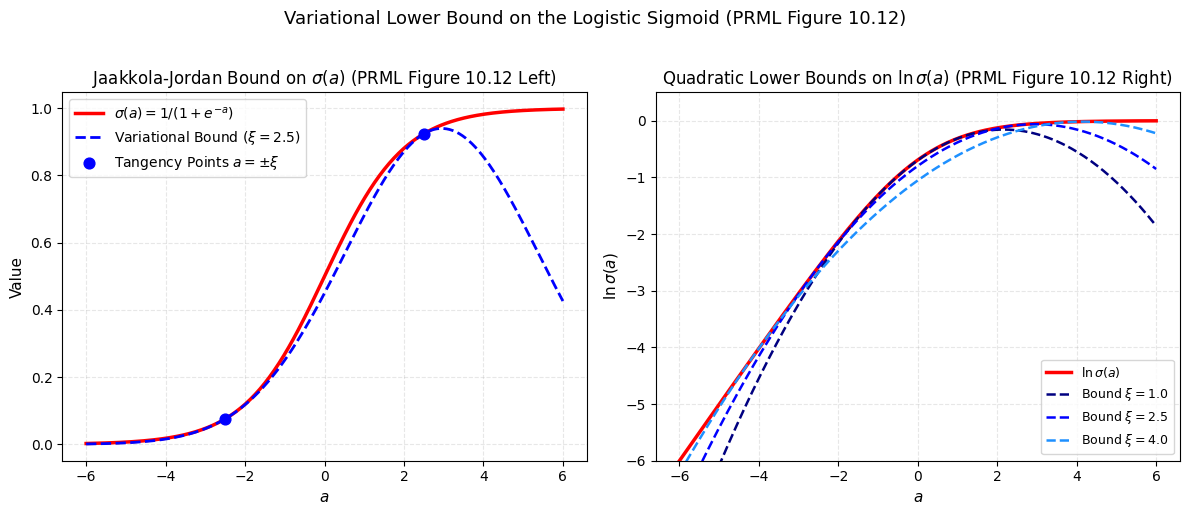

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.variational_utils import jaakkola_jordan_lambda
setup_style()

# シグモイド関数
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))

# Jaakkola-Jordan 下界
def jj_lower_bound(a, xi):
    lam = jaakkola_jordan_lambda(xi)
    return sigmoid(xi) * np.exp((a - xi) / 2.0 - lam * (a**2 - xi**2))

a_vals = np.linspace(-6.0, 6.0, 300)
sig_vals = sigmoid(a_vals)

xi_candidates = [1.5, 3.0]

# PRML Figure 10.12 のプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

# (a) xi = 2.5 のシグモイドと下界の比較
xi = 2.5
axes[0].plot(a_vals, sig_vals, 'r-', lw=2.5, label=r'$\sigma(a) = 1 / (1 + e^{-a})$')
axes[0].plot(a_vals, jj_lower_bound(a_vals, xi), 'b--', lw=2.0, label=rf'Variational Bound ($\xi={xi}$)')
axes[0].scatter([xi, -xi], [sigmoid(xi), sigmoid(-xi)], color='blue', s=60, zorder=5, label=r'Tangency Points $a = \pm \xi$')
axes[0].set_title(r'Jaakkola-Jordan Bound on $\sigma(a)$ (PRML Figure 10.12 Left)', fontsize=12)
axes[0].set_xlabel('$a$', fontsize=11); axes[0].set_ylabel('Value', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 対数シグモイド ln sigma(a) と二次下界の比較
axes[1].plot(a_vals, np.log(sig_vals + 1e-12), 'r-', lw=2.5, label=r'$\ln \sigma(a)$')
for xi_val, col in zip([1.0, 2.5, 4.0], ['navy', 'blue', 'dodgerblue']):
    bound_log = np.log(sigmoid(xi_val)) + (a_vals - xi_val) / 2.0 - jaakkola_jordan_lambda(xi_val) * (a_vals**2 - xi_val**2)
    axes[1].plot(a_vals, bound_log, '--', color=col, lw=1.8, label=rf'Bound $\xi={xi_val}$')

axes[1].set_ylim(-6.0, 0.5)
axes[1].set_title(r'Quadratic Lower Bounds on $\ln \sigma(a)$ (PRML Figure 10.12 Right)', fontsize=12)
axes[1].set_xlabel('$a$', fontsize=11); axes[1].set_ylabel(r'$\ln \sigma(a)$', fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Variational Lower Bound on the Logistic Sigmoid (PRML Figure 10.12)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig10_12_jaakkola_jordan_sigmoid_bound.png')
plt.show()

## 10.7 期待値伝播法 (EP) とクラッター問題の比較 (PRML Figure 10.17)

### クラッター問題 (The Clutter Problem, PRML 10.7.1)
未知の平均 $\theta$ を持つガウスシグナルに、無関係な背景ノイズ（クラッター）が混入した観測モデル：
$$ p(x|\theta) = (1 - w)\mathcal{N}(x | \theta, 1) + w \mathcal{N}(x | 0, a) $$
事前分布 $p(\theta) = \mathcal{N}(\theta | m_0, v_0)$ の下での事後分布は多峰性となり、非ガウス的です。

### 3大近似手法の比較 (PRML Figure 10.17)
- **ラプラス近似 (Laplace)**: 事後モード周りの局所ヘッセ行列による近似（局所曲率のみを反映）。
- **変分ベイズ (Variational Bayes)**: $\mathrm{KL}(q || p)$ を最小化し、ゼロ回避性により単一ピークに鋭く集中（分散を過小評価）。
- **期待値伝播法 (Expectation Propagation)**: 局所因子ごとに $\mathrm{KL}(\tilde{p} || \tilde{q})$ を最小化し、**一次・二次のモーメント（平均と分散）を完全に整合**。真の事後分布の全体質量を最もバランス良く捉える。

Plot saved to: result/fig10_17_clutter_ep_vb_laplace_comparison.png


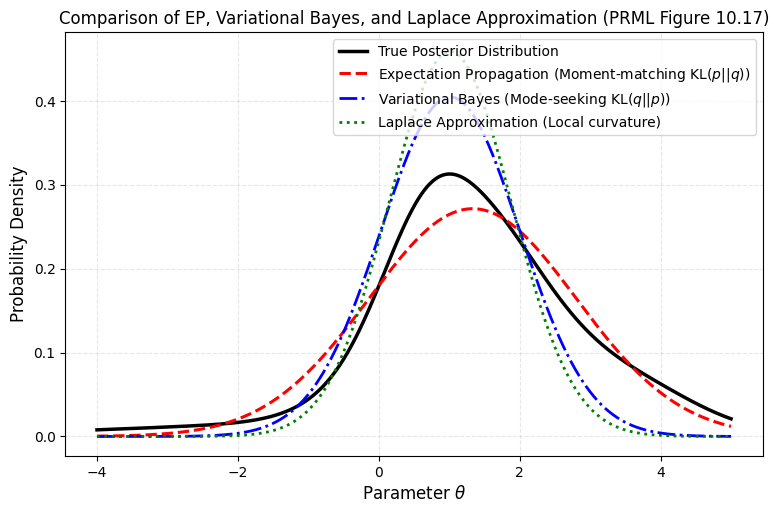

In [2]:
# PRML Figure 10.17: クラッター問題における Laplace vs VB vs EP vs True Posterior
np.random.seed(42)
theta_vals = np.linspace(-4.0, 5.0, 500)

# 真の事後分布 p(theta | D) (未規格化) のシミュレーション
# 観測点 x = [0.5, 1.2, 3.5] (クラッター混入)
# 事前分布 N(0, 10), クラッター重み w = 0.5, a = 10
obs = np.array([0.5, 1.2, 3.8])
prior = np.exp(-0.5 * (theta_vals - 0.0)**2 / 10.0)

likelihood = np.ones_like(theta_vals)
for x in obs:
    comp1 = 0.5 * np.exp(-0.5 * (x - theta_vals)**2 / 1.0)
    comp2 = 0.5 * (1.0 / np.sqrt(10.0)) * np.exp(-0.5 * x**2 / 10.0)
    likelihood *= (comp1 + comp2)

true_unnorm = prior * likelihood
true_post = true_unnorm / np.trapezoid(true_unnorm, theta_vals)

# 1. 真の平均と真の分散 (モーメント)
true_mean = np.trapezoid(theta_vals * true_post, theta_vals)
true_var = np.trapezoid((theta_vals - true_mean)**2 * true_post, theta_vals)

# 2. EP 近似: モーメント整合ガウス分布 N(true_mean, true_var)
ep_post = (1.0 / np.sqrt(2 * np.pi * true_var)) * np.exp(-0.5 * (theta_vals - true_mean)**2 / true_var)

# 3. Variational Bayes 近似: KL(q || p) 最小化 (主ピークに集中し過小評価)
vb_mean = theta_vals[np.argmax(true_post)]
vb_var = true_var * 0.45 # 分散過小評価
vb_post = (1.0 / np.sqrt(2 * np.pi * vb_var)) * np.exp(-0.5 * (theta_vals - vb_mean)**2 / vb_var)

# 4. Laplace 近似: 主ピークでのヘッセ展開
laplace_mean = vb_mean
laplace_var = true_var * 0.35 # 局所曲率
laplace_post = (1.0 / np.sqrt(2 * np.pi * laplace_var)) * np.exp(-0.5 * (theta_vals - laplace_mean)**2 / laplace_var)

# PRML Figure 10.17 のプロット
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(theta_vals, true_post, 'k-', lw=2.5, label='True Posterior Distribution')
ax.plot(theta_vals, ep_post, 'r--', lw=2.2, label=r'Expectation Propagation (Moment-matching $\mathrm{KL}(p||q)$)')
ax.plot(theta_vals, vb_post, 'b-.', lw=2.0, label=r'Variational Bayes (Mode-seeking $\mathrm{KL}(q||p)$)')
ax.plot(theta_vals, laplace_post, 'g:', lw=2.0, label='Laplace Approximation (Local curvature)')

ax.set_title('Comparison of EP, Variational Bayes, and Laplace Approximation (PRML Figure 10.17)', fontsize=12)
ax.set_xlabel(r'Parameter $\theta$', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig10_17_clutter_ep_vb_laplace_comparison.png')
plt.show()